In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import nibabel as nib

In [2]:
experiment_path = (
    "/Users/clairenastaskin/data/2025-05-07/sub-Forest001_ses-20250507_task-movements_run-001/"
)
task_event_path = os.path.join(experiment_path, "task_events.csv")
frame_times_path = os.path.join(experiment_path, "frame_times.npy")
fusi_path = os.path.join(experiment_path, "fUSi_data_after_processing.nii.gz")


task_events = pd.read_csv(task_event_path)
frame_times = np.load(frame_times_path)
fusi_data = nib.load(fusi_path)
fusi_data = fusi_data.get_fdata()

In [3]:
timecourse = fusi_data[88,32,98,:]
np.save(
    os.path.join(experiment_path, "timecourse_coord_88-32-98_rightwristminusleftwristZscore0-9_rightwristZscore4-3_leftwrsitZscore5_mouthZscore7-3.npy"),
    timecourse
)


In [4]:
print(timecourse.shape)
print(frame_times.shape)
print(task_events)

(259,)
(259,)
                trial_type       onset  duration
0    left_wrist_motion.mp4    5.891488    10.991
1      move_your_mouth.mp4   35.892488    10.174
2      move_your_mouth.mp4   64.668488    10.725
3   right_wrist_motion.mp4   94.509488    10.171
4    left_wrist_motion.mp4  124.188488    10.181
5      move_your_mouth.mp4  152.634488    10.597
6    tap_right_fingers.mp4  181.323488    10.609
7      move_right_foot.mp4  212.801488    10.578
8      move_right_foot.mp4  243.616488    10.950
9    tap_right_fingers.mp4  274.980488    10.370
10   left_wrist_motion.mp4  306.103488    10.005
11      move_left_foot.mp4  334.976488    10.021
12     move_right_foot.mp4  365.376488    10.436
13     move_your_mouth.mp4  395.265488    10.463
14   tap_right_fingers.mp4  424.609488    10.542
15   tap_right_fingers.mp4  454.129488    10.931
16  right_wrist_motion.mp4  485.560488    10.563
17   tap_right_fingers.mp4  516.204488    10.740
18     move_right_foot.mp4  545.002488    10.037
19    

In [5]:
power_doppler_time_course = pd.DataFrame(
    {
        "timestamp": frame_times,
        "power_doppler_value": timecourse,
    }
)

In [6]:
task_list_type = task_events.trial_type.unique()
print(task_list_type)

['left_wrist_motion.mp4' 'move_your_mouth.mp4' 'right_wrist_motion.mp4'
 'tap_right_fingers.mp4' 'move_right_foot.mp4' 'move_left_foot.mp4']


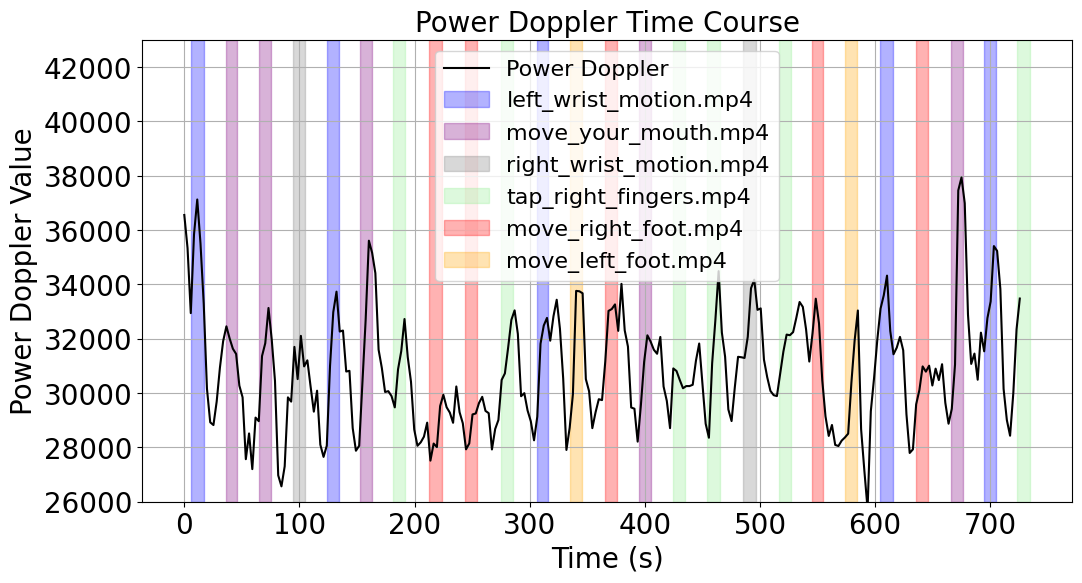

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(
    power_doppler_time_course.timestamp,
    power_doppler_time_course.power_doppler_value,
    color="black",
    label="Power Doppler"
)

task_colors = ['blue','purple', 'gray', 'lightgreen','red','orange','yellow','pink']

# Add colored rectangles for stimulus periods
for task_index in range(len(task_list_type)):
    task = task_list_type[task_index]
    task_events_timing = pd.DataFrame()
    task_events_timing["Event"] = ["start", "stop"] * len(
        task_events[task_events["trial_type"] == task]
    )
    task_events_timing["Timestamp"] = [
        onset
        for onset, duration in zip(
            task_events[task_events["trial_type"] == task]["onset"],
            task_events[task_events["trial_type"] == task]["duration"],
        )
        for _ in range(2)
    ]
    task_events_timing.loc[task_events_timing["Event"] == "stop", "Timestamp"] += (
        task_events[task_events["trial_type"] == task]["duration"].values.repeat(1)
    )
    task_events_timing = task_events_timing.sort_values("Timestamp").reset_index(drop=True)
    start_times = task_events_timing[task_events_timing["Event"] == "start"]["Timestamp"]
    stop_times = task_events_timing[task_events_timing["Event"] == "stop"]["Timestamp"]
    for start, stop in zip(start_times, stop_times):
        plt.axvspan(start, stop, color=task_colors[task_index], alpha=0.3, label=task if start == start_times.iloc[0] else "")

plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Power Doppler Value", fontsize=20)
plt.title("Power Doppler Time Course", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(26000, 43000)
plt.grid(True)
plt.legend(fontsize=16)
plt.show()

